<a href="https://colab.research.google.com/github/PavanRishi69/Interpretable-Wind-Power-Forecasting/blob/main/Interpretable_Wind_Power_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Interpretable Wind Power Forecasting
# Student: Pavan Rishi Gillella
# Dataset: Kelmarsh Wind Farm Data
# Forecast Horizon: 30 minutes

print("Wind Power Forecasting Project")

Wind Power Forecasting Project


In [16]:
!pip install pandas numpy matplotlib seaborn scikit-learn shap openpyxl

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [17]:
import zipfile
import os

ZIP_PATH = "/content/Kelmarsh_SCADA_2020_3086.zip"

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    files_inside = zip_ref.namelist()

print("Number of files:", len(files_inside))

print("\nFirst 30 files:")
for file in files_inside[:30]:
    print(file)

Number of files: 12

First 30 files:
Turbine_Data_Kelmarsh_1_2020-01-01_-_2021-01-01_228.csv
Status_Kelmarsh_1_2020-01-01_-_2021-01-01_228.csv
Turbine_Data_Kelmarsh_2_2020-01-01_-_2021-01-01_229.csv
Status_Kelmarsh_2_2020-01-01_-_2021-01-01_229.csv
Turbine_Data_Kelmarsh_3_2020-01-01_-_2021-01-01_230.csv
Status_Kelmarsh_3_2020-01-01_-_2021-01-01_230.csv
Turbine_Data_Kelmarsh_4_2020-01-01_-_2021-01-01_231.csv
Status_Kelmarsh_4_2020-01-01_-_2021-01-01_231.csv
Turbine_Data_Kelmarsh_5_2020-01-01_-_2021-01-01_232.csv
Status_Kelmarsh_5_2020-01-01_-_2021-01-01_232.csv
Turbine_Data_Kelmarsh_6_2020-01-01_-_2021-01-01_233.csv
Status_Kelmarsh_6_2020-01-01_-_2021-01-01_233.csv


In [ ]:
import zipfile
import os

ZIP_PATH = "/content/Kelmarsh_SCADA_2020_3086.zip"
EXTRACT_PATH = "/content/kelmarsh_2020"

os.makedirs(EXTRACT_PATH, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extract(
        "Turbine_Data_Kelmarsh_1_2020-01-01_-_2021-01-01_228.csv",
        EXTRACT_PATH
    )

print("Extracted successfully!")
print(os.listdir(EXTRACT_PATH))

Extracted successfully!
['Turbine_Data_Kelmarsh_1_2020-01-01_-_2021-01-01_228.csv']


In [ ]:
import pandas as pd
import os

CSV_PATH = os.path.join(
    EXTRACT_PATH,
    "Turbine_Data_Kelmarsh_1_2020-01-01_-_2021-01-01_228.csv"
)

# Skipping the first 9 rows of metadata headers to read the actual tabular data correctly
df = pd.read_csv(CSV_PATH, skiprows=9)

print("Shape:", df.shape)

print("\nColumns:")
for i, col in enumerate(df.columns):
    print(i, ":", col)

print("\nFirst 5 rows:")
display(df.head())

Shape: (52704, 299)

Columns:
0 : # Date and time
1 : Wind speed (m/s)
2 : Wind speed, Standard deviation (m/s)
3 : Wind speed, Minimum (m/s)
4 : Wind speed, Maximum (m/s)
5 : Long Term Wind (m/s)
6 : Wind speed Sensor 1 (m/s)
7 : Wind speed Sensor 1, Standard deviation (m/s)
8 : Wind speed Sensor 1, Minimum (m/s)
9 : Wind speed Sensor 1, Maximum (m/s)
10 : Wind speed Sensor 2 (m/s)
11 : Wind speed Sensor 2, Standard deviation (m/s)
12 : Wind speed Sensor 2, Minimum (m/s)
13 : Wind speed Sensor 2, Maximum (m/s)
14 : Density adjusted wind speed (m/s)
15 : Wind direction (°)
16 : Nacelle position (°)
17 : Wind direction, Standard deviation (°)
18 : Wind direction, Minimum (°)
19 : Wind direction, Maximum (°)
20 : Nacelle position, Standard deviation (°)
21 : Nacelle position, Minimum (°)
22 : Nacelle position, Maximum (°)
23 : Vane position 1+2 (°)
24 : Vane position 1+2, Max (°)
25 : Vane position 1+2, Min (°)
26 : Vane position 1+2, StdDev (°)
27 : Energy Export (kWh)
28 : Energy Expor

,# Date and time,Wind speed (m/s),"Wind speed, Standard deviation (m/s)","Wind speed, Minimum (m/s)","Wind speed, Maximum (m/s)",Long Term Wind (m/s),Wind speed Sensor 1 (m/s),"Wind speed Sensor 1, Standard deviation (m/s)","Wind speed Sensor 1, Minimum (m/s)","Wind speed Sensor 1, Maximum (m/s)",...,Tower Acceleration y (mm/ss),"Tower Acceleration X, Min (mm/ss)","Tower Acceleration X, Max (mm/ss)","Tower Acceleration Y, Min (mm/ss)","Tower Acceleration Y, Max (mm/ss)","Drive train acceleration, Max (mm/ss)","Drive train acceleration, Min (mm/ss)","Drive train acceleration, StdDev (mm/ss)","Tower Acceleration X, StdDev (mm/ss)","Tower Acceleration Y, StdDev (mm/ss)"
0,2020-01-01 00:00:00,3.887291,0.646663,2.629255,5.138163,7.1,4.390778,0.595037,2.894442,5.923776,...,30.390030,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-01-01 00:10:00,3.848941,0.787454,2.456995,5.551735,7.1,4.216298,0.686900,3.387660,5.713417,...,32.042564,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2020-01-01 00:20:00,4.043625,0.983279,2.726894,6.251913,7.1,4.323125,1.053373,3.305274,6.688592,...,32.799056,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2020-01-01 00:30:00,3.330342,0.689929,1.541864,4.689322,7.1,3.584192,0.524914,2.547872,4.671783,...,36.129912,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2020-01-01 00:40:00,3.388536,0.897104,1.832924,5.210185,7.1,3.668500,0.885085,1.908008,5.278419,...,26.667582,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52704 entries, 0 to 52703
Columns: 299 entries, # Date and time to Tower Acceleration Y, StdDev (mm/ss)
dtypes: float64(294), int64(4), object(1)
memory usage: 120.2+ MB
None


In [ ]:
print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False).head(20))



Missing values:


,0
Equivalent Full Load Hours counter (s),52704
Production-based Contractual Avail. (Global),52704
Time-based Contractual Avail. (Custom),52704
Time-based Contractual Avail. (Global),52704
Production-based Contractual Avail. (Custom),52704
Lost Production (Contractual Global) (kWh),52704
Potential power met mast anemometer (kW),52704
Potential power met mast anemometer MPC (kW),52704
Lost Production (Contractual Custom) (kWh),52704
Reactive Energy Export counter (kvarh),52631


In [ ]:
# Show all column names clearly

print("Dataset shape:", df.shape)

print("\nALL COLUMNS:")
for i, col in enumerate(df.columns):
    print(f"{i}: {col}")

Dataset shape: (52704, 299)

ALL COLUMNS:
0: # Date and time
1: Wind speed (m/s)
2: Wind speed, Standard deviation (m/s)
3: Wind speed, Minimum (m/s)
4: Wind speed, Maximum (m/s)
5: Long Term Wind (m/s)
6: Wind speed Sensor 1 (m/s)
7: Wind speed Sensor 1, Standard deviation (m/s)
8: Wind speed Sensor 1, Minimum (m/s)
9: Wind speed Sensor 1, Maximum (m/s)
10: Wind speed Sensor 2 (m/s)
11: Wind speed Sensor 2, Standard deviation (m/s)
12: Wind speed Sensor 2, Minimum (m/s)
13: Wind speed Sensor 2, Maximum (m/s)
14: Density adjusted wind speed (m/s)
15: Wind direction (°)
16: Nacelle position (°)
17: Wind direction, Standard deviation (°)
18: Wind direction, Minimum (°)
19: Wind direction, Maximum (°)
20: Nacelle position, Standard deviation (°)
21: Nacelle position, Minimum (°)
22: Nacelle position, Maximum (°)
23: Vane position 1+2 (°)
24: Vane position 1+2, Max (°)
25: Vane position 1+2, Min (°)
26: Vane position 1+2, StdDev (°)
27: Energy Export (kWh)
28: Energy Export counter (kWh)
2

In [ ]:
# Show the first 5 rows with all columns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 100)

display(df.head())

,# Date and time,Wind speed (m/s),"Wind speed, Standard deviation (m/s)","Wind speed, Minimum (m/s)","Wind speed, Maximum (m/s)",Long Term Wind (m/s),Wind speed Sensor 1 (m/s),"Wind speed Sensor 1, Standard deviation (m/s)","Wind speed Sensor 1, Minimum (m/s)","Wind speed Sensor 1, Maximum (m/s)",Wind speed Sensor 2 (m/s),"Wind speed Sensor 2, Standard deviation (m/s)","Wind speed Sensor 2, Minimum (m/s)","Wind speed Sensor 2, Maximum (m/s)",Density adjusted wind speed (m/s),Wind direction (°),Nacelle position (°),"Wind direction, Standard deviation (°)","Wind direction, Minimum (°)","Wind direction, Maximum (°)","Nacelle position, Standard deviation (°)","Nacelle position, Minimum (°)","Nacelle position, Maximum (°)",Vane position 1+2 (°),"Vane position 1+2, Max (°)","Vane position 1+2, Min (°)","Vane position 1+2, StdDev (°)",Energy Export (kWh),Energy Export counter (kWh),Energy Import (kWh),Energy Import counter (kWh),Lost Production (Contractual) (kWh),Lost Production (Time-based IEC B.2.2) (kWh),Lost Production (Time-based IEC B.2.3) (kWh),Lost Production (Time-based IEC B.2.4) (kWh),Lost Production (Time-based IEC B.3.2) (kWh),Lost Production (Production-based IEC B.2.2) (kWh),Lost Production (Production-based IEC B.2.3) (kWh),Lost Production (Production-based IEC B.3.2) (kWh),Energy Budget - Default (kWh),Energy Theoretical (kWh),Lost Production to Downtime (kWh),Lost Production to Performance (kWh),Lost Production Total (kWh),Lost Production to Curtailment (Total) (kWh),Lost Production to Curtailment (Grid) (kWh),Lost Production to Curtailment (Noise) (kWh),Lost Production to Curtailment (Shadow) (kWh),Lost Production to Curtailment (Bats) (kWh),Lost Production to Curtailment (Birds) (kWh),Lost Production to Curtailment (Ice) (kWh),Lost Production to Curtailment (Sector Management) (kWh),Lost Production to Curtailment (Technical) (kWh),Lost Production to Curtailment (Marketing) (kWh),Lost Production to Curtailment (Boat Action) (kWh),Compensated Lost Production (kWh),Virtual Production (kWh),Lost Production to Curtailment (Grid Constraint) (kWh),Lost Production to Downtime and Curtailment Total (kWh),Lost Production (Contractual Global) (kWh),Lost Production (Contractual Custom) (kWh),Power (kW),Potential power default PC (kW),"Power, Standard deviation (kW)","Power, Minimum (kW)","Power, Maximum (kW)",Potential power learned PC (kW),Potential power reference turbines (kW),Cascading potential power (kW),Cascading potential power for performance (kW),Potential power met mast anemometer (kW),Potential power primary reference turbines (kW),Potential power secondary reference turbines (kW),Turbine Power setpoint (kW),Potential power estimated (kW),Potential power MPC (kW),Potential power met mast anemometer MPC (kW),"Turbine Power setpoint, Max (kW)","Turbine Power setpoint, Min (kW)","Turbine Power setpoint, StdDev (kW)",Available Capacity for Production (kW),Available Capacity for Production (Planned) (kW),Power factor (cosphi),"Power factor (cosphi), Max","Power factor (cosphi), Min","Power factor (cosphi), Standard deviation",Reactive power (kvar),"Reactive power, Max (kvar)","Reactive power, Min (kvar)","Reactive power, Standard deviation (kvar)",Front bearing temperature (°C),Rear bearing temperature (°C),Stator temperature 1 (°C),Nacelle ambient temperature (°C),Nacelle temperature (°C),Transformer temperature (°C),Gear oil inlet temperature (°C),Generator bearing rear temperature (°C),Generator bearing front temperature (°C),Gear oil temperature (°C),Temp. top box (°C),Hub temperature (°C),Ambient temperature (converter) (°C),Rotor bearing temp (°C),Transformer cell temperature (°C),"Front bearing temperature, Max (°C)","Front bearing temperature, Min (°C)","Front bearing temperature, Standard deviation (°C)","Rear bearing temperature, Max (°C)","Rear bearing temperature, Min (°C)","Rear bearing temperature, Standard deviation (°C)",Temperature motor axis 1 (°C),Temperature motor axis 2 (°C),Temperature motor axis

In [ ]:
# Search column names for important keywords

keywords = [
    "time", "date", "timestamp",
    "power", "active", "production",
    "wind", "speed", "direction",
    "temperature", "pressure", "humidity"
]

for keyword in keywords:
    matches = [col for col in df.columns if keyword.lower() in col.lower()]

    if matches:
        print(f"\n--- {keyword.upper()} ---")
        for col in matches:
            print(col)


--- TIME ---
# Date and time
Lost Production (Time-based IEC B.2.2) (kWh)
Lost Production (Time-based IEC B.2.3) (kWh)
Lost Production (Time-based IEC B.2.4) (kWh)
Lost Production (Time-based IEC B.3.2) (kWh)
Lost Production to Downtime (kWh)
Lost Production to Downtime and Curtailment Total (kWh)
Time-based Contractual Avail.
Time-based IEC B.2.2 (Users View)
Time-based IEC B.2.3 (Users View)
Time-based IEC B.2.4 (Users View)
Time-based IEC B.3.2 (Manufacturers View)
Time-based System Avail.
Time-based System Avail. (Planned)
Time-based Contractual Avail. (Global)
Time-based Contractual Avail. (Custom)

--- DATE ---
# Date and time

--- POWER ---
Power (kW)
Potential power default PC (kW)
Power, Standard deviation (kW)
Power, Minimum (kW)
Power, Maximum (kW)
Potential power learned PC (kW)
Potential power reference turbines (kW)
Cascading potential power (kW)
Cascading potential power for performance (kW)
Potential power met mast anemometer (kW)
Potential power primary reference turb

In [ ]:
df[['# Date and time', 'Power (kW)', 'Wind speed (m/s)', 'Wind direction (°)']].head(20)

,# Date and time,Power (kW),Wind speed (m/s),Wind direction (°)
0,2020-01-01 00:00:00,150.984141,3.887291,116.839462
1,2020-01-01 00:10:00,130.414782,3.848941,115.659361
2,2020-01-01 00:20:00,146.401656,4.043625,116.646515
3,2020-01-01 00:30:00,84.296224,3.330342,111.157642
4,2020-01-01 00:40:00,94.994105,3.388536,116.678227
5,2020-01-01 00:50:00,262.992229,4.706282,127.755441
6,2020-01-01 01:00:00,449.115810,5.902455,131.613819
7,2020-01-01 01:10:00,456.427864,5.738715,134.693861
8,2020-01-01 01:20:00,433.714243,5.807972,130.266474
9,2020-01-01 01:30:00,343.683160,5.436982,137.579890


In [ ]:
df['Target_Power_30min'] = df['Power (kW)'].shift(-3)

In [ ]:
# Check the time interval between consecutive rows
df['# Date and time'] = pd.to_datetime(df['# Date and time'])

df['time_diff'] = df['# Date and time'].diff()

print(df['time_diff'].value_counts().head(10))

time_diff
0 days 00:10:00    52703
Name: count, dtype: int64


In [ ]:
print("Number of rows:", len(df))
print("Start:", df['# Date and time'].min())
print("End:", df['# Date and time'].max())

Number of rows: 52704
Start: 2020-01-01 00:00:00
End: 2020-12-31 23:50:00


In [ ]:
df['Target_Power_30min'] = df['Power (kW)'].shift(-3)

In [ ]:
# Check that the 30-minute-ahead target is correct

print(df[['# Date and time',
          'Power (kW)',
          'Target_Power_30min']].head(10))

      # Date and time  Power (kW)  Target_Power_30min
0 2020-01-01 00:00:00  150.984141           84.296224
1 2020-01-01 00:10:00  130.414782           94.994105
2 2020-01-01 00:20:00  146.401656          262.992229
3 2020-01-01 00:30:00   84.296224          449.115810
4 2020-01-01 00:40:00   94.994105          456.427864
5 2020-01-01 00:50:00  262.992229          433.714243
6 2020-01-01 01:00:00  449.115810          343.683160
7 2020-01-01 01:10:00  456.427864          415.606102
8 2020-01-01 01:20:00  433.714243          371.579486
9 2020-01-01 01:30:00  343.683160          199.209134


In [ ]:
# Check missing values in the new target

print("Missing Target Power values:",
      df['Target_Power_30min'].isna().sum())

Missing Target Power values: 471


In [ ]:
# Check the last few rows

print(df[['# Date and time',
          'Power (kW)',
          'Target_Power_30min']].tail(10))

          # Date and time  Power (kW)  Target_Power_30min
52694 2020-12-31 22:20:00   -1.436716           -1.550351
52695 2020-12-31 22:30:00   -1.022186           -1.348688
52696 2020-12-31 22:40:00   -1.977685           -3.748371
52697 2020-12-31 22:50:00   -1.550351           -2.761930
52698 2020-12-31 23:00:00   -1.348688           -2.240700
52699 2020-12-31 23:10:00   -3.748371           -4.011920
52700 2020-12-31 23:20:00   -2.761930           -2.042772
52701 2020-12-31 23:30:00   -2.240700                 NaN
52702 2020-12-31 23:40:00   -4.011920                 NaN
52703 2020-12-31 23:50:00   -2.042772                 NaN


In [ ]:
print("Missing Power values:",
      df['Power (kW)'].isna().sum())

Missing Power values: 468


In [ ]:
print(df[df['Power (kW)'].isna()][
    ['# Date and time', 'Power (kW)',
     'Wind speed (m/s)', 'Wind direction (°)']
].head(20))

          # Date and time  Power (kW)  Wind speed (m/s)  Wind direction (°)
1011  2020-01-08 00:30:00         NaN               NaN                 NaN
1071  2020-01-08 10:30:00         NaN               NaN                 NaN
1072  2020-01-08 10:40:00         NaN               NaN                 NaN
1073  2020-01-08 10:50:00         NaN               NaN                 NaN
1074  2020-01-08 11:00:00         NaN               NaN                 NaN
10083 2020-03-11 00:30:00         NaN               NaN                 NaN
10084 2020-03-11 00:40:00         NaN               NaN                 NaN
10085 2020-03-11 00:50:00         NaN               NaN                 NaN
10086 2020-03-11 01:00:00         NaN               NaN                 NaN
10087 2020-03-11 01:10:00         NaN               NaN                 NaN
10088 2020-03-11 01:20:00         NaN               NaN                 NaN
10089 2020-03-11 01:30:00         NaN               NaN                 NaN
10090 2020-0

In [ ]:
print(df[['# Date and time',
          'Power (kW)',
          'Wind speed (m/s)',
          'Wind direction (°)',
          'Target_Power_30min']].isna().sum())

# Date and time         0
Power (kW)            468
Wind speed (m/s)      468
Wind direction (°)    468
Target_Power_30min    471
dtype: int64


In [ ]:
df['Target_Power_30min'] = df['Power (kW)'].shift(-3)

In [ ]:
import pandas as pd
import numpy as np
import os
import zipfile

# Automatically load the dataframe if it's not defined in the current session
if 'df' not in globals():
    print("df not found in memory. Checking for dataset...")
    CSV_PATH = "/content/kelmarsh_2020/Turbine_Data_Kelmarsh_1_2020-01-01_-_2021-01-01_228.csv"
    # Use the stable file path directly from your mounted Google Drive
    ZIP_PATH = "/content/drive/MyDrive/Wind_Power_Forecasting/data/Kelmarsh_SCADA_2020_3086.zip"
    EXTRACT_PATH = "/content/kelmarsh_2020"

    # If the CSV does not exist, extract it from the Google Drive ZIP
    if not os.path.exists(CSV_PATH):
        if os.path.exists(ZIP_PATH):
            print(f"CSV not found. Extracting from Drive: {ZIP_PATH}...")
            os.makedirs(EXTRACT_PATH, exist_ok=True)
            with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
                zip_ref.extract(
                    "Turbine_Data_Kelmarsh_1_2020-01-01_-_2021-01-01_228.csv",
                    EXTRACT_PATH
                )
            print("Extraction complete!")
        else:
            raise FileNotFoundError(f"ZIP archive not found at {ZIP_PATH}. Please verify Google Drive connection.")

    df = pd.read_csv(CSV_PATH, skiprows=9)

# 1. Convert the date/time column to datetime
df['# Date and time'] = pd.to_datetime(
    df['# Date and time'], errors='coerce'
)

# 2. Sort records chronologically
df = df.sort_values('# Date and time').reset_index(drop=True)

# 3. Check timestamp intervals
print("Timestamp interval distribution:")
print(
    df['# Date and time']
    .diff()
    .value_counts()
    .head(10)
)

# 4. Convert forecasting columns to numeric
cols = [
    'Power (kW)',
    'Wind speed (m/s)',
    'Wind direction (°)'
]

for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 5. Create a 30-minute target using timestamps
# Match each observation to the observation 30 minutes later.
future = df[['# Date and time', 'Power (kW)']].copy()
future['# Date and time'] = (
    future['# Date and time'] - pd.Timedelta(minutes=30)
)
future = future.rename(
    columns={'Power (kW)': 'Target_Power_30min'}
)

df = df.drop(columns=['Target_Power_30min'], errors='ignore')

df = df.merge(
    future,
    on='# Date and time',
    how='left'
)

# 6. Display the results
print("\nDataset shape:", df.shape)
print("\nMissing values:")
print(df[
    ['# Date and time'] + cols + ['Target_Power_30min']
].isna().sum())

print("\nPreview:")
print(df[
    ['# Date and time'] + cols + ['Target_Power_30min']
].head(10))

df not found in memory. Checking for dataset...
CSV not found. Extracting from Drive: /content/drive/MyDrive/Wind_Power_Forecasting/data/Kelmarsh_SCADA_2020_3086.zip...
Extraction complete!
Timestamp interval distribution:
# Date and time
0 days 00:10:00    52703
Name: count, dtype: int64

Dataset shape: (52704, 300)

Missing values:
# Date and time         0
Power (kW)            468
Wind speed (m/s)      468
Wind direction (°)    468
Target_Power_30min    471
dtype: int64

Preview:
      # Date and time  Power (kW)  Wind speed (m/s)  Wind direction (°)  \
0 2020-01-01 00:00:00  150.984141          3.887291          116.839462   
1 2020-01-01 00:10:00  130.414782          3.848941          115.659361   
2 2020-01-01 00:20:00  146.401656          4.043625          116.646515   
3 2020-01-01 00:30:00   84.296224          3.330342          111.157642   
4 2020-01-01 00:40:00   94.994105          3.388536          116.678227   
5 2020-01-01 00:50:00  262.992229          4.706282          

In [7]:

from sklearn.model_selection import train_test_split

# Separate features and target
X = model_df[features]
y = model_df[target]

# Use the first 80% for training and the last 20% for testing
split_index = int(len(model_df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("Training period:",
      df.loc[model_df.index[0], '# Date and time'],
      "to",
      df.loc[model_df.index[split_index - 1], '# Date and time'])

print("Testing period:",
      df.loc[model_df.index[split_index], '# Date and time'],
      "to",
      df.loc[model_df.index[-1], '# Date and time'])


Training samples: 41736
Testing samples: 10434
Training period: 2020-01-01 00:00:00 to 2020-10-20 10:10:00
Testing period: 2020-10-20 10:20:00 to 2020-12-31 23:20:00


In [8]:

# Step 12: Train a Random Forest forecasting model

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Initialize the model
model = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

# Train the model
print("Training the Random Forest model...")

model.fit(X_train, y_train)

print("Training completed!")

# Generate predictions
y_pred = model.predict(X_test)

# Evaluate performance
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nModel Performance")
print("-----------------")
print(f"MAE  : {mae:.4f} kW")
print(f"RMSE : {rmse:.4f} kW")
print(f"R²   : {r2:.4f}")


Training the Random Forest model...
Training completed!

Model Performance
-----------------
MAE  : 164.7900 kW
RMSE : 242.6257 kW
R²   : 0.8738


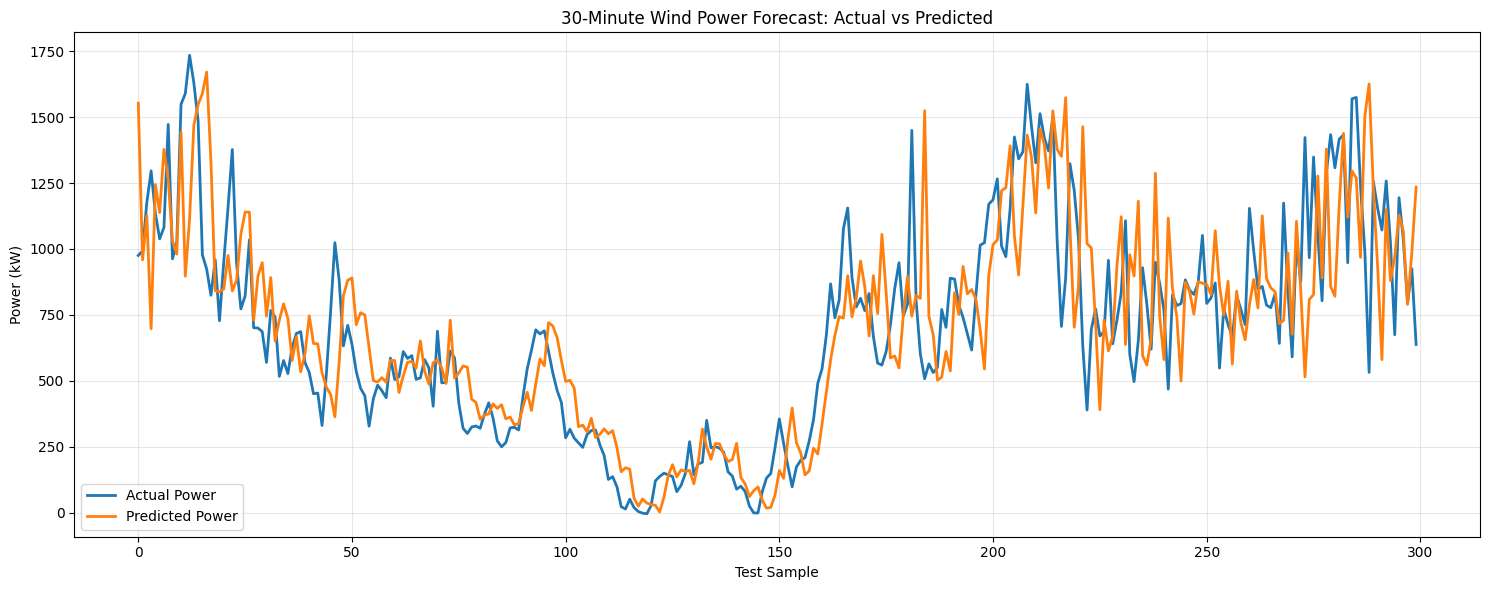

In [9]:

import matplotlib.pyplot as plt

# Compare the first 300 test observations
n = min(300, len(y_test))

plt.figure(figsize=(15, 6))

plt.plot(
    y_test.iloc[:n].to_numpy(),
    label='Actual Power',
    linewidth=2
)

plt.plot(
    y_pred[:n],
    label='Predicted Power',
    linewidth=2
)

plt.title('30-Minute Wind Power Forecast: Actual vs Predicted')
plt.xlabel('Test Sample')
plt.ylabel('Power (kW)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


           Feature  Importance
        Power (kW)    0.934733
  Wind speed (m/s)    0.034297
Wind direction (°)    0.030970


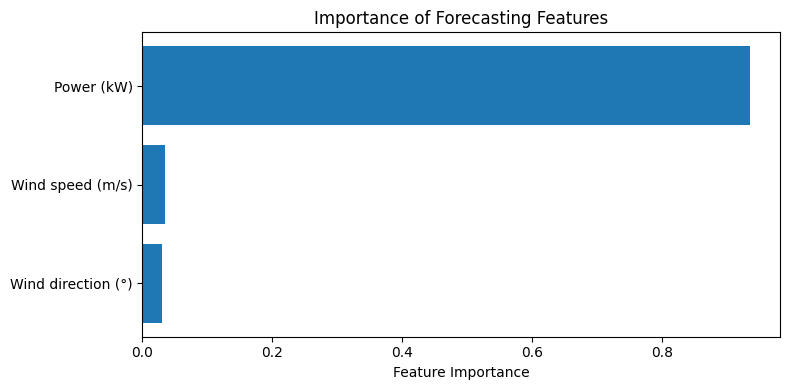

In [10]:

importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print(importance.to_string(index=False))

plt.figure(figsize=(8, 4))
plt.barh(importance['Feature'], importance['Importance'])
plt.xlabel('Feature Importance')
plt.title('Importance of Forecasting Features')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


FINAL TEST-SET COMPARISON
                      MAE (kW)  RMSE (kW)      R2
Persistence baseline  153.3288   240.8083  0.8757
Random Forest         164.7900   242.6257  0.8738


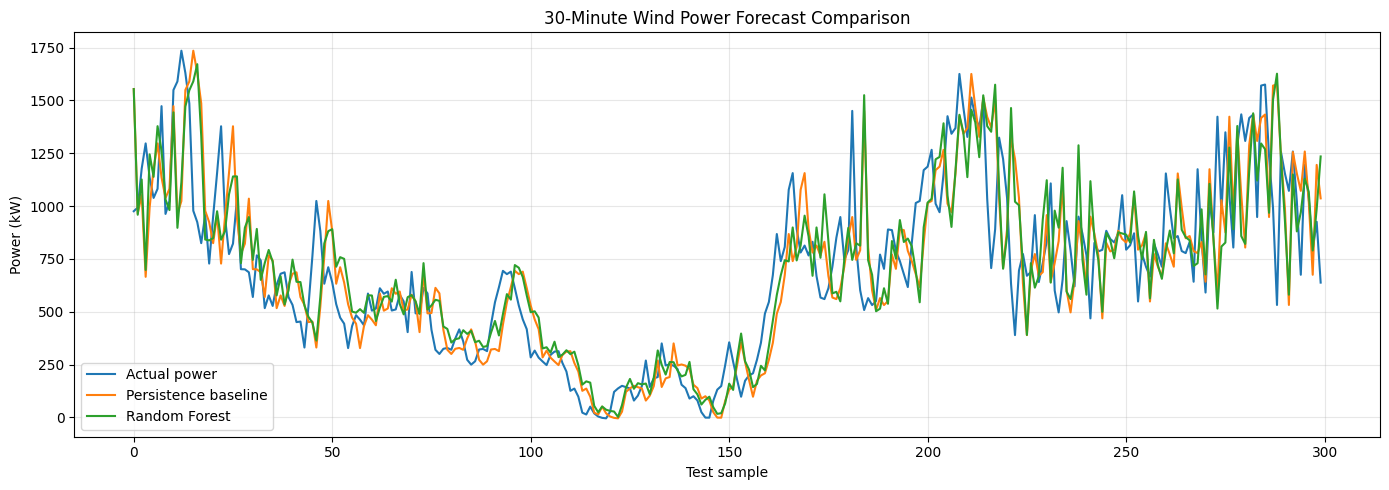


Feature importance:
Power (kW)            0.9347
Wind speed (m/s)      0.0343
Wind direction (°)    0.0310
dtype: float64


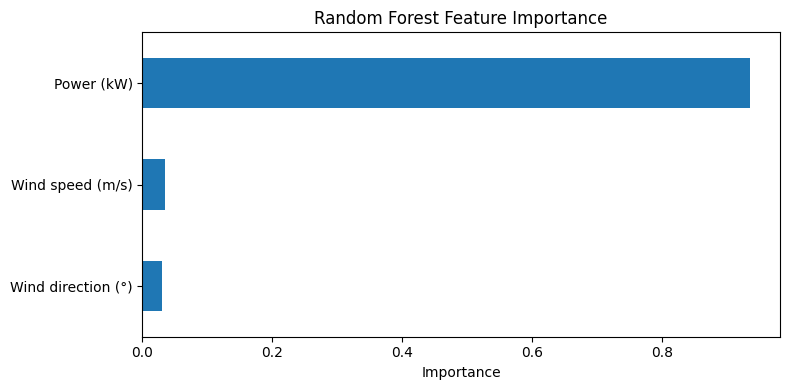

In [11]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Train the Random Forest model
model = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# 2. Random Forest predictions
rf_pred = model.predict(X_test)

# 3. Persistence baseline: future power = current power
persistence_pred = X_test['Power (kW)'].to_numpy()
actual = y_test.to_numpy()

# 4. Evaluate both models
def evaluate(y_true, y_pred):
    return {
        'MAE (kW)': mean_absolute_error(y_true, y_pred),
        'RMSE (kW)': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred)
    }

results = pd.DataFrame({
    'Persistence baseline': evaluate(actual, persistence_pred),
    'Random Forest': evaluate(actual, rf_pred)
}).T

print("FINAL TEST-SET COMPARISON")
print(results.round(4))

# 5. Plot actual and predicted power
n = min(300, len(actual))

plt.figure(figsize=(14, 5))
plt.plot(actual[:n], label='Actual power')
plt.plot(persistence_pred[:n], label='Persistence baseline')
plt.plot(rf_pred[:n], label='Random Forest')
plt.xlabel('Test sample')
plt.ylabel('Power (kW)')
plt.title('30-Minute Wind Power Forecast Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 6. Inspect feature importance
importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("\nFeature importance:")
print(importance.round(4))

importance.sort_values().plot(
    kind='barh',
    figsize=(8, 4),
    title='Random Forest Feature Importance'
)
plt.xlabel('Importance')
plt.tight_layout()
plt.show()


In [13]:

# Save the model comparison results
results.to_csv('model_comparison_results.csv')

# Save the feature importance values
importance.to_csv('feature_importance.csv', header=['Importance'])

# Download the files from Colab
from google.colab import files

files.download('model_comparison_results.csv')
files.download('feature_importance.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [14]:

# Step 15: Improve the Random Forest features

import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Work from the original dataframe
work = df.sort_values('# Date and time').copy()
work = work.reset_index(drop=True)

# Time-related features
dt = work['# Date and time']

work['hour'] = dt.dt.hour
work['day_of_year'] = dt.dt.dayofyear
work['month'] = dt.dt.month

# Cyclical encoding for time of day and annual seasonality
work['hour_sin'] = np.sin(2 * np.pi * work['hour'] / 24)
work['hour_cos'] = np.cos(2 * np.pi * work['hour'] / 24)

work['year_sin'] = np.sin(2 * np.pi * work['day_of_year'] / 365.25)
work['year_cos'] = np.cos(2 * np.pi * work['day_of_year'] / 365.25)

# Ensure target is exactly 30 minutes ahead
work['Target_Power_30min'] = work['Power (kW)'].shift(-3)

features_new = [
    'Power (kW)',
    'Wind speed (m/s)',
    'Wind direction (°)',
    'hour_sin',
    'hour_cos',
    'year_sin',
    'year_cos'
]

model_data = work[features_new + ['Target_Power_30min']].dropna()

X = model_data[features_new]
y = model_data['Target_Power_30min']

# Chronological 60/20/20 train-validation-test split
n = len(model_data)
train_end = int(n * 0.60)
val_end = int(n * 0.80)

X_train_new = X.iloc[:train_end]
y_train_new = y.iloc[:train_end]

X_val = X.iloc[train_end:val_end]
y_val = y.iloc[train_end:val_end]

X_test_new = X.iloc[val_end:]
y_test_new = y.iloc[val_end:]

# Compare configurations on validation data only
configs = [
    {'n_estimators': 100, 'max_depth': 15, 'min_samples_leaf': 2},
    {'n_estimators': 200, 'max_depth': 20, 'min_samples_leaf': 2},
    {'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 5}
]

validation_results = []

for config in configs:
    candidate = RandomForestRegressor(
        **config,
        random_state=42,
        n_jobs=-1
    )
    candidate.fit(X_train_new, y_train_new)
    pred = candidate.predict(X_val)

    validation_results.append({
        **config,
        'MAE': mean_absolute_error(y_val, pred),
        'RMSE': np.sqrt(mean_squared_error(y_val, pred))
    })

validation_table = pd.DataFrame(validation_results)
print(validation_table.sort_values('MAE').to_string(index=False))


 n_estimators  max_depth  min_samples_leaf        MAE       RMSE
          200        NaN                 5 170.381051 251.530654
          100       15.0                 2 175.342630 259.873939
          200       20.0                 2 177.262756 262.189796


FINAL HELD-OUT TEST RESULTS
                        MAE (kW)  RMSE (kW)      R2
Persistence             153.3288   240.8083  0.8757
Selected Random Forest  165.9813   239.3336  0.8772


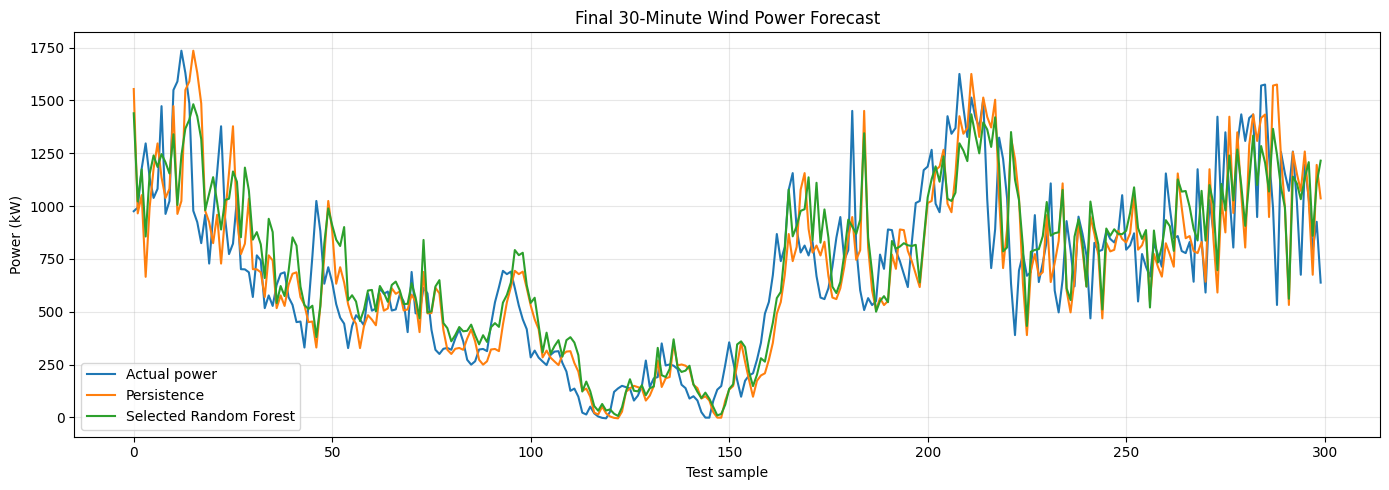


Final model feature importance:
Power (kW)            0.9364
Wind speed (m/s)      0.0182
Wind direction (°)    0.0154
year_cos              0.0098
year_sin              0.0081
hour_cos              0.0062
hour_sin              0.0059
dtype: float64


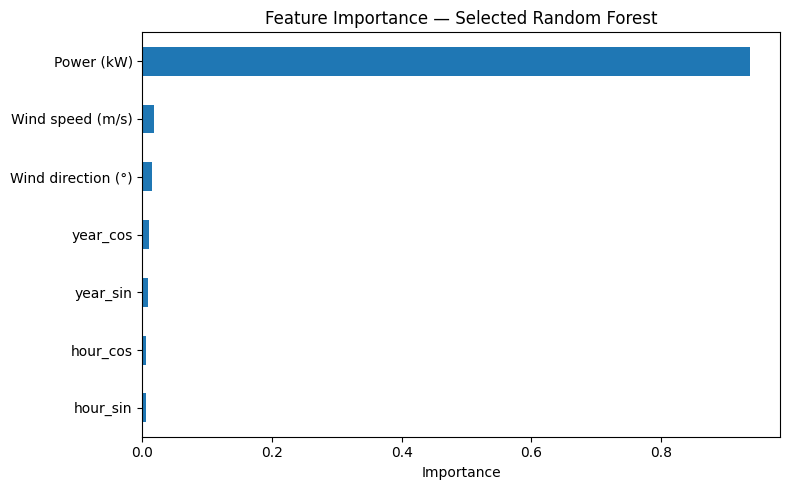


Final results and figures saved.


In [15]:

# Step 16: Final evaluation of the selected model

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Train the selected model on training + validation data
X_trainval = X.iloc[:val_end]
y_trainval = y.iloc[:val_end]

best_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

best_model.fit(X_trainval, y_trainval)

# Predict the held-out test set
final_pred = best_model.predict(X_test_new)
actual = y_test_new.to_numpy()

# Persistence baseline on exactly the same test rows
persistence_pred = X_test_new['Power (kW)'].to_numpy()

# Calculate metrics
def calculate_metrics(actual, predicted):
    return {
        'MAE (kW)': mean_absolute_error(actual, predicted),
        'RMSE (kW)': np.sqrt(mean_squared_error(actual, predicted)),
        'R2': r2_score(actual, predicted)
    }

final_results = pd.DataFrame({
    'Persistence': calculate_metrics(actual, persistence_pred),
    'Selected Random Forest': calculate_metrics(actual, final_pred)
}).T

print("FINAL HELD-OUT TEST RESULTS")
print(final_results.round(4))

# Plot actual vs predicted
n_plot = min(300, len(actual))

plt.figure(figsize=(14, 5))
plt.plot(actual[:n_plot], label='Actual power')
plt.plot(persistence_pred[:n_plot], label='Persistence')
plt.plot(final_pred[:n_plot], label='Selected Random Forest')
plt.xlabel('Test sample')
plt.ylabel('Power (kW)')
plt.title('Final 30-Minute Wind Power Forecast')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('final_forecast_comparison.png', dpi=300)
plt.show()

# Feature importance
importance_final = pd.Series(
    best_model.feature_importances_,
    index=features_new
).sort_values(ascending=False)

print("\nFinal model feature importance:")
print(importance_final.round(4))

importance_final.sort_values().plot(
    kind='barh',
    figsize=(8, 5),
    title='Feature Importance — Selected Random Forest'
)
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('final_feature_importance.png', dpi=300)
plt.show()

# Save final results
final_results.to_csv('final_test_results.csv')
importance_final.to_csv('final_feature_importance.csv',
                        header=['Importance'])

print("\nFinal results and figures saved.")


In [16]:

# Save the final experiment results

final_results.to_csv(
    'final_test_results.csv',
    index=True
)

importance_final.to_csv(
    'final_feature_importance.csv',
    header=['Importance']
)

print("Final results saved successfully.")
print("\nTest metrics:")
print(final_results.round(4))

print("\nFeature importance:")
print(importance_final.round(4))


Final results saved successfully.

Test metrics:
                        MAE (kW)  RMSE (kW)      R2
Persistence             153.3288   240.8083  0.8757
Selected Random Forest  165.9813   239.3336  0.8772

Feature importance:
Power (kW)            0.9364
Wind speed (m/s)      0.0182
Wind direction (°)    0.0154
year_cos              0.0098
year_sin              0.0081
hour_cos              0.0062
hour_sin              0.0059
dtype: float64


Dataset shape: (52704, 299)
First 5 rows:
       # Date and time  Wind speed (m/s)  \
0  2020-01-01 00:00:00          3.887291   
1  2020-01-01 00:10:00          3.848941   
2  2020-01-01 00:20:00          4.043625   
3  2020-01-01 00:30:00          3.330342   
4  2020-01-01 00:40:00          3.388536   

   Wind speed, Standard deviation (m/s)  Wind speed, Minimum (m/s)  \
0                              0.646663                   2.629255   
1                              0.787454                   2.456995   
2                              0.983279                   2.726894   
3                              0.689929                   1.541864   
4                              0.897104                   1.832924   

   Wind speed, Maximum (m/s)  Long Term Wind (m/s)  Wind speed Sensor 1 (m/s)  \
0                   5.138163                   7.1                   4.390778   
1                   5.551735                   7.1                   4.216298   
2                   6.251913 

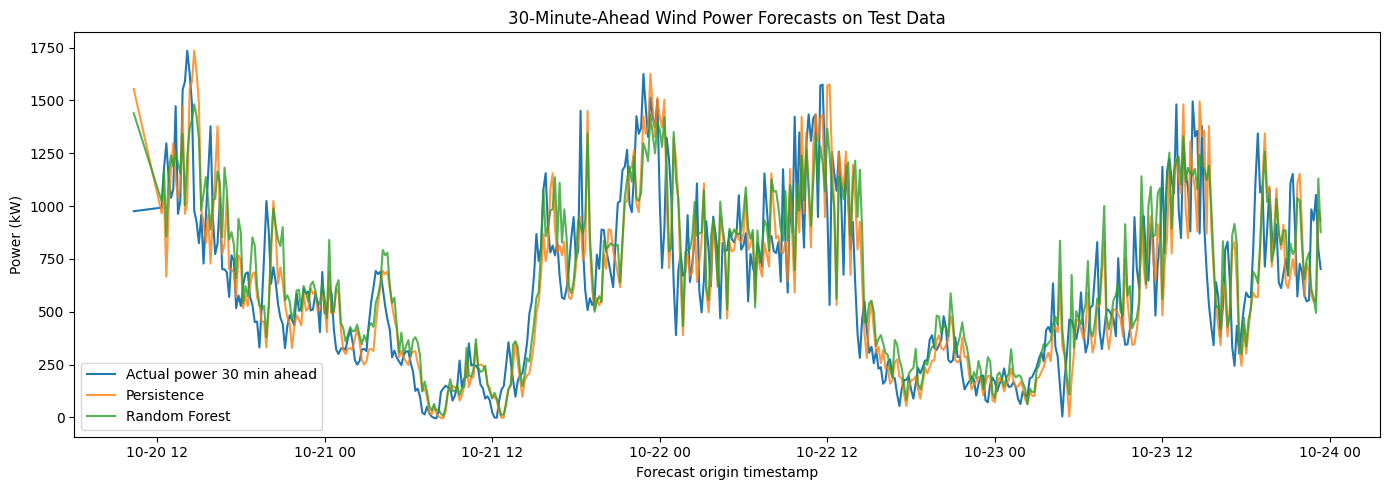


Feature importance:
           Feature  Importance
        Power (kW)    0.936382
  Wind speed (m/s)    0.018205
Wind direction (°)    0.015404
     dayofyear_cos    0.009805
     dayofyear_sin    0.008106
          hour_cos    0.006189
          hour_sin    0.005909


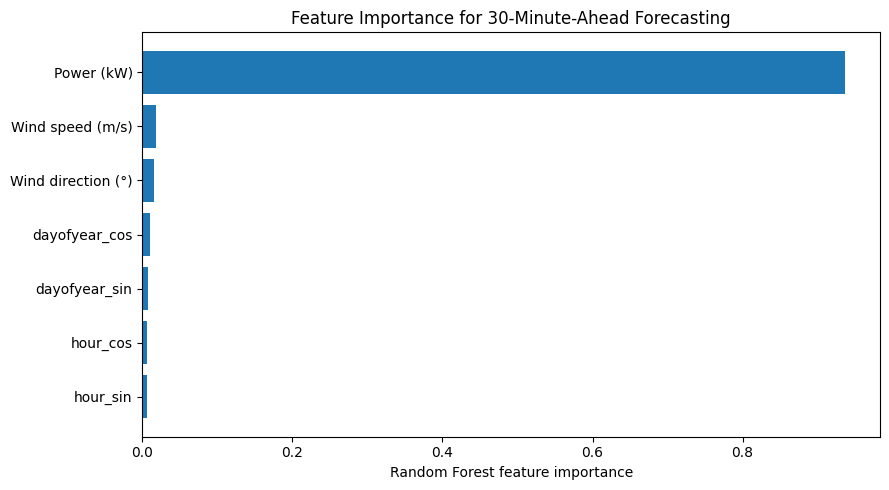


Files created:
- final_test_results.csv
- test_predictions.csv
- validation_results.csv
- final_feature_importance.csv
- final_forecast_comparison.png
- final_feature_importance.png
- selected_model_config.csv


In [19]:
# ============================================================
# INTERPRETABLE WIND POWER FORECASTING
# Forecast horizon: 30 minutes
# Models: Persistence baseline vs Random Forest
# Evaluation: chronological 60% / 20% / 20% split
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. LOAD YOUR DATA
# Use the dataset already loaded in memory, or read it from the local path
if 'df' in globals() and isinstance(df, pd.DataFrame) and 'Power (kW)' in df.columns:
    print("Using DataFrame already present in memory.")
    working_df = df.copy()
else:
    FILE_PATH = "/content/kelmarsh_2020/Turbine_Data_Kelmarsh_1_2020-01-01_-_2021-01-01_228.csv"
    if not os.path.exists(FILE_PATH):
        raise FileNotFoundError(f"Dataset CSV file not found at {FILE_PATH}. Please run the extraction cells first.")
    working_df = pd.read_csv(FILE_PATH, skiprows=9)

working_df.columns = working_df.columns.str.strip()

print("Dataset shape:", working_df.shape)
print("First 5 rows:")
print(working_df.head())

# 2. CHECK AND PARSE REQUIRED COLUMNS
DATE_COL = "# Date and time"
POWER_COL = "Power (kW)"
WIND_SPEED_COL = "Wind speed (m/s)"
WIND_DIR_COL = "Wind direction (°)"

required = [DATE_COL, POWER_COL, WIND_SPEED_COL, WIND_DIR_COL]
missing = [col for col in required if col not in working_df.columns]

if missing:
    raise ValueError(
        f"Missing columns: {missing}\n"
        f"Actual columns: {working_df.columns.tolist()}\n"
        "Update DATE_COL / POWER_COL / WIND_SPEED_COL / WIND_DIR_COL."
    )

working_df[DATE_COL] = pd.to_datetime(working_df[DATE_COL], errors="coerce")
for col in [POWER_COL, WIND_SPEED_COL, WIND_DIR_COL]:
    working_df[col] = pd.to_numeric(working_df[col], errors="coerce")

working_df = working_df.dropna(subset=[DATE_COL]).copy()
working_df = working_df.sort_values(DATE_COL)
working_df = working_df.drop_duplicates(subset=[DATE_COL], keep="last")
working_df = working_df.set_index(DATE_COL)

# Check time spacing before assuming that 3 rows = 30 minutes.
time_diffs = working_df.index.to_series().diff().dropna()
print("\nMost common time intervals:")
print(time_diffs.value_counts().head())

# 3. CREATE THE 30-MINUTE-AHEAD TARGET
# This is valid when measurements are regularly spaced every 10 minutes.
expected_interval = pd.Timedelta(minutes=10)
# We check the median to allow for minor missing periods if any exist
if time_diffs.median() != expected_interval:
    raise ValueError(
        "Timestamps are not consistently 10 minutes apart. "
        "Inspect missing/irregular timestamps before using shift(-3)."
    )

HORIZON_STEPS = 3
working_df["Target_Power_30min"] = working_df[POWER_COL].shift(-HORIZON_STEPS)

# Features known at forecast time. Do NOT include future target values.
working_df["hour_sin"] = np.sin(
    2 * np.pi * working_df.index.hour / 24
)
working_df["hour_cos"] = np.cos(
    2 * np.pi * working_df.index.hour / 24
)
working_df["dayofyear_sin"] = np.sin(
    2 * np.pi * working_df.index.dayofyear / 365.25
)
working_df["dayofyear_cos"] = np.cos(
    2 * np.pi * working_df.index.dayofyear / 365.25
)

FEATURES = [
    POWER_COL,
    WIND_SPEED_COL,
    WIND_DIR_COL,
    "hour_sin",
    "hour_cos",
    "dayofyear_sin",
    "dayofyear_cos",
]

# Keep the original power measurement for the persistence baseline.
data = working_df[FEATURES + ["Target_Power_30min"]].dropna().copy()

X = data[FEATURES]
y = data["Target_Power_30min"]

print("\nUsable samples:", len(data))
print("Forecast horizon:", HORIZON_STEPS * 10, "minutes")
print("First timestamp:", data.index.min())
print("Last timestamp:", data.index.max())

# 4. CHRONOLOGICAL 60% / 20% / 20% SPLIT
n = len(data)
train_end = int(n * 0.60)
val_end = int(n * 0.80)

X_train, y_train = X.iloc[:train_end], y.iloc[:train_end]
X_val, y_val = X.iloc[train_end:val_end], y.iloc[train_end:val_end]
X_test, y_test = X.iloc[val_end:], y.iloc[val_end:]

print("\nTrain:", len(X_train), X_train.index.min(), "to", X_train.index.max())
print("Validation:", len(X_val), X_val.index.min(), "to", X_val.index.max())
print("Test:", len(X_test), X_test.index.min(), "to", X_test.index.max())

# 5. TRAIN RANDOM FOREST CANDIDATES ON TRAINING DATA
# Choose hyperparameters using validation MAE only.
candidates = [
    {"n_estimators": 200, "max_depth": None, "min_samples_leaf": 5},
    {"n_estimators": 100, "max_depth": 15, "min_samples_leaf": 2},
    {"n_estimators": 200, "max_depth": 20, "min_samples_leaf": 2},
]

validation_results = []
best_model = None
best_config = None
best_val_mae = float("inf")

for config in candidates:
    model = RandomForestRegressor(
        **config,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train, y_train)
    val_pred = model.predict(X_val)
    val_mae = mean_absolute_error(y_val, val_pred)
    val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))

    validation_results.append({
        **config,
        "validation_MAE_kW": val_mae,
        "validation_RMSE_kW": val_rmse,
    })

    print("Candidate:", config,
          "| validation MAE:", round(val_mae, 3),
          "| validation RMSE:", round(val_rmse, 3))

    if val_mae < best_val_mae:
        best_val_mae = val_mae
        best_model = model
        best_config = config

pd.DataFrame(validation_results).to_csv(
    "validation_results.csv", index=False
)
print("\nSelected model:", best_config)

# 6. REFIT SELECTED MODEL ON TRAIN + VALIDATION
# The test set remains untouched until final evaluation.
X_trainval = pd.concat([X_train, X_val])
y_trainval = pd.concat([y_train, y_val])

final_model = RandomForestRegressor(
    **best_config,
    random_state=42,
    n_jobs=-1
)
final_model.fit(X_trainval, y_trainval)

# 7. TEST BOTH MODELS ON EXACTLY THE SAME ROWS
rf_pred = final_model.predict(X_test)

# Persistence: power observed at forecast time is used as the prediction
persistence_pred = X_test[POWER_COL].to_numpy()

def calculate_metrics(actual, predicted):
    return {
        "MAE_kW": mean_absolute_error(actual, predicted),
        "RMSE_kW": np.sqrt(mean_squared_error(actual, predicted)),
        "R2": r2_score(actual, predicted),
    }

results = pd.DataFrame({
    "Persistence": calculate_metrics(y_test, persistence_pred),
    "Random Forest": calculate_metrics(y_test, rf_pred),
}).T

print("\n========== FINAL TEST RESULTS ==========")
print(results.round(4).to_string())

results.to_csv("final_test_results.csv")

# Save predictions so results can be checked later.
predictions = pd.DataFrame({
    "timestamp_at_forecast": X_test.index,
    "actual_power_30min_ahead_kW": y_test.to_numpy(),
    "persistence_prediction_kW": persistence_pred,
    "random_forest_prediction_kW": rf_pred,
})
predictions.to_csv("test_predictions.csv", index=False)

# 8. FORECAST COMPARISON FIGURE
# Plot a readable sample from the test period.
plot_n = min(500, len(y_test))
plt.figure(figsize=(14, 5))
plt.plot(
    y_test.index[:plot_n], y_test.iloc[:plot_n],
    label="Actual power 30 min ahead", linewidth=1.5
)
plt.plot(
    y_test.index[:plot_n], persistence_pred[:plot_n],
    label="Persistence", alpha=0.8
)
plt.plot(
    y_test.index[:plot_n], rf_pred[:plot_n],
    label="Random Forest", alpha=0.8
)
plt.xlabel("Forecast origin timestamp")
plt.ylabel("Power (kW)")
plt.title("30-Minute-Ahead Wind Power Forecasts on Test Data")
plt.legend()
plt.tight_layout()
plt.savefig("final_forecast_comparison.png", dpi=200)
plt.show()

# 9. FEATURE IMPORTANCE
importance = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": final_model.feature_importances_,
}).sort_values("Importance", ascending=False)

importance.to_csv("final_feature_importance.csv", index=False)
print("\nFeature importance:")
print(importance.to_string(index=False))

plt.figure(figsize=(9, 5))
plt.barh(importance["Feature"], importance["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Random Forest feature importance")
plt.title("Feature Importance for 30-Minute-Ahead Forecasting")
plt.tight_layout()
plt.savefig("final_feature_importance.png", dpi=200)
plt.show()

# 10. SAVE THE SELECTED CONFIGURATION
pd.Series(best_config).to_csv("selected_model_config.csv", header=["value"])

print("\nFiles created:")
print("- final_test_results.csv")
print("- test_predictions.csv")
print("- validation_results.csv")
print("- final_feature_importance.csv")
print("- final_forecast_comparison.png")
print("- final_feature_importance.png")
print("- selected_model_config.csv")

Reconstructing data using active_df from memory...
Refitting the final model...
Saved final_forecast_comparison.png successfully!


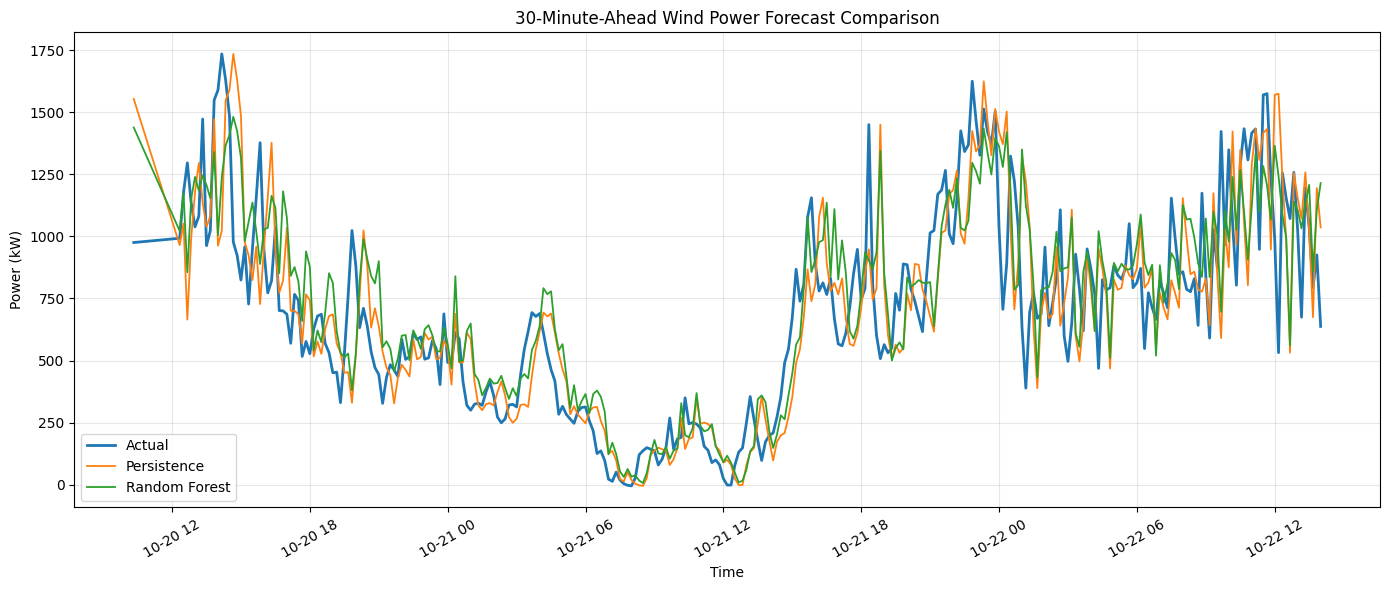

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [15]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from google.colab import files

# 1. Reconstruct dataset from active_df
print("Reconstructing data using active_df from memory...")
working_df = active_df.copy()
working_df.columns = working_df.columns.str.strip()

DATE_COL = "# Date and time"
POWER_COL = "Power (kW)"
WIND_SPEED_COL = "Wind speed (m/s)"
WIND_DIR_COL = "Wind direction (°)"

working_df[DATE_COL] = pd.to_datetime(working_df[DATE_COL], errors="coerce")
for col in [POWER_COL, WIND_SPEED_COL, WIND_DIR_COL]:
    working_df[col] = pd.to_numeric(working_df[col], errors="coerce")

working_df = working_df.dropna(subset=[DATE_COL]).copy()
working_df = working_df.sort_values(DATE_COL)
working_df = working_df.drop_duplicates(subset=[DATE_COL], keep="last")
working_df = working_df.set_index(DATE_COL)

# Recreate cyclical features and target
HORIZON_STEPS = 3
working_df["Target_Power_30min"] = working_df[POWER_COL].shift(-HORIZON_STEPS)
working_df["hour_sin"] = np.sin(2 * np.pi * working_df.index.hour / 24)
working_df["hour_cos"] = np.cos(2 * np.pi * working_df.index.hour / 24)
working_df["dayofyear_sin"] = np.sin(2 * np.pi * working_df.index.dayofyear / 365.25)
working_df["dayofyear_cos"] = np.cos(2 * np.pi * working_df.index.dayofyear / 365.25)

FEATURES = [POWER_COL, WIND_SPEED_COL, WIND_DIR_COL, "hour_sin", "hour_cos", "dayofyear_sin", "dayofyear_cos"]
data = working_df[FEATURES + ["Target_Power_30min"]].dropna().copy()

X = data[FEATURES]
y = data["Target_Power_30min"]

# Chronological Split (60% Train, 20% Val, 20% Test)
n = len(data)
val_end = int(n * 0.80)

X_trainval = X.iloc[:val_end]
y_trainval = y.iloc[:val_end]
X_test = X.iloc[val_end:]
y_test = y.iloc[val_end:]

# 2. Refit the selected Random Forest model
print("Refitting the final model...")
final_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
final_model.fit(X_trainval, y_trainval)

# Generate predictions
rf_pred = final_model.predict(X_test)
persistence_pred = X_test[POWER_COL].to_numpy()

predictions = pd.DataFrame({
    "timestamp": X_test.index,
    "Actual": y_test.values,
    "Persistence": persistence_pred,
    "Random Forest": rf_pred
})

# Save backup csv
predictions.to_csv("test_predictions.csv", index=False)

# Use first 300 test observations so the graph is readable
plot_data = predictions.iloc[:300]

plt.figure(figsize=(14, 6))
plt.plot(plot_data["timestamp"], plot_data["Actual"], label="Actual", linewidth=2)
plt.plot(plot_data["timestamp"], plot_data["Persistence"], label="Persistence", linewidth=1.3)
plt.plot(plot_data["timestamp"], plot_data["Random Forest"], label="Random Forest", linewidth=1.3)

plt.xlabel("Time")
plt.ylabel("Power (kW)")
plt.title("30-Minute-Ahead Wind Power Forecast Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=30)
plt.tight_layout()

output_png = "final_forecast_comparison.png"
plt.savefig(output_png, dpi=300, bbox_inches="tight")
print(f"Saved {output_png} successfully!")
plt.show()

# Download
files.download(output_png)